# Prompt to AI
I am working on an NLP project analyzing a large corpus of AI and technology news articles. I have already completed data cleaning and topic modeling, and I now have a column called `clean_text` and topic assignments for each document.

I want you to build a full **entity extraction pipeline** in Python to identify organizations, companies, technologies, and key entities mentioned in the articles.

Please write clean, runnable Python code and explain each step briefly. The pipeline should be efficient enough to handle a large dataset (100k–200k articles).

Build the pipeline with the following steps:

1. **Load the dataset**

   * Load the dataset (CSV or Parquet) into a pandas DataFrame.
   * Ensure the dataset contains `clean_text` and `topic` columns.
   * Remove rows where `clean_text` is missing.

2. **Load an NER model**

   * Use spaCy for named entity recognition.
   * Load a strong English model (e.g., `en_core_web_trf`)
   * Configure the pipeline for efficient batch processing.

3. **Define target entity types**
   Extract entities such as:

   * ORG (companies, institutions)
   * PRODUCT (AI models, software)
   * GPE (locations when relevant to companies)
   * PERSON (important figures in AI)
   * TECH-related terms (optional custom matcher)

4. **Process the dataset in batches**

   * Use `nlp.pipe()` for fast processing.
   * Add progress bars using `tqdm`.
   * Extract entities for each document.

5. **Store extracted entities**
   Create structured outputs such as:

   * `entities_all`: list of all entities per document
   * `org_entities`: organizations mentioned

6. **Create entity frequency tables**
   Build aggregated tables showing:

   * entity name
   * entity type
   * frequency count
   * number of documents mentioned

7. **Link entities to topics**
   Aggregate entity counts by topic to identify which entities dominate each topic cluster.

8. **Clean entity outputs**

   * Normalize capitalization
   * Remove noise entities (numbers, generic words)
   * Merge duplicates if needed (e.g., “OpenAI” vs “openai”).

9. **Peform Visualization**


In [ ]:
import pandas as pd
from google.colab import drive

from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [ ]:
df = pd.read_parquet(
    "/content/drive/MyDrive/NLP Final Project/docs_with_topics.parquet"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NLP Final Project/docs_with_topics.parquet'

In [ ]:
topic_labels = {
    0: "AI Image Generation & Creative Tools",
    1: "U.S. Federal Politics",
    2: "Clinical Research & Biotech",
    3: "Crypto Trading & Market Tools",
    4: "Startups & Venture Ecosystem",
    5: "Stock Markets & Earnings",
    6: "Regional Media & Press Distribution",
    7: "Indian National Politics",
    8: "Press Release Distribution Services",
    9: "Smartphones & Consumer Devices",
    10: "Public Broadcasting & Arts Media",
    11: "ChatGPT & AI Tools",
    12: "Chinese AI & Tech Competition",
    13: "Semiconductors & GPUs",
    14: "Climate & Renewable Energy",
    15: "Middle East Financial Markets",
    16: "Cybersecurity & Threat Intelligence",
    17: "OpenAI Leadership & Governance",
    18: "AI Copyright & Legal Disputes",
    19: "Developer Tools & Productivity Apps",
    20: "E-Commerce & Conversational AI",
    21: "Music Streaming & Digital Music Industry",
    22: "Crypto & Stock Investing (NFTs / Pharma / E-commerce)",
    23: "Texas Local News & Policy Updates",
    24: "Data Science Salaries & Recruiting",
    25: "Academic Integrity & ChatGPT in Education",
    26: "Entertainment Industry & Studios (SAG-AFTRA / Marvel)",
    27: "Google AI Ecosystem (Gemini / Android / Pixel)",
    28: "Generative Video Tools (Sora / Firefly / Text-to-Video)",
    29: "Automotive Engineering & Logistics",
    30: "Data Science Education & Skills",
    31: "West African Regional News",
    32: "New Mexico Local News",
    33: "Website Access & Login Systems",
    34: "Equities Markets & Stock Analysis",
    35: "Microsoft Copilot & Consumer Tech",
    36: "Dating, Mental Health & Relationships",
    37: "Legal Affairs & Financial Regulation",
    38: "Singapore News & Lifestyle Media",
    39: "Mobile Devices & Consumer Gadgets",
    40: "Home Electronics & Appliances",
    41: "Travel & Seasonal Lifestyle Content",
    42: "Global Sports & Premier League",
    43: "UAE Business & Regional Economy",
    44: "Philanthropy & Nonprofit Initiatives",
    45: "AI Content Creation & Enterprise Tools",
    46: "Public Radio & Cultural Programming",
    47: "Crypto Exchanges & Token Markets",
    48: "China Chip Exports & Trade Controls",
    49: "Crypto Technical Analysis & Indicators",
    50: "Telecom Industry & Sustainability Insights",
    51: "Forex Trading & Gold Markets",
    52: "Elon Musk, xAI & Grok AI",
    53: "Tech Bulletins & Educational Resources",
    54: "Crypto Price Forecasting & Volatility",
    55: "Restaurants & Food Industry",
    56: "Catholic Church & Vatican Affairs",
    57: "Canadian Regional News",
    58: "Central Asia Energy & Geopolitics",
    59: "Idaho Public Media & Local News",
    60: "Maryland & Virginia Community News",
    61: "Tesla, SpaceX & AI Robotics",
    62: "Enterprise Consulting & Digital Transformation",
    63: "The Beatles & Classic Rock Media",
    64: "Gaming Platforms & Security Updates",
    65: "Colorado Local News & Weather",
    66: "Pakistan National News",
    67: "Digital Art & Creative Design",
    68: "Sports Betting & Gambling Industry",
    69: "Gaza Conflict & Middle East War",
    70: "AI Assistants & Regional Tech News",
    71: "Asian Wellness & Lifestyle Media",
    72: "Macro Markets, Fed & Crypto",
    73: "Louisiana Regional News",
    74: "Voice Cloning & Fraud Risks",
    75: "Religious Tolerance & Human Rights",
    76: "Midwest Public Radio & Community News",
    77: "Ohio Regional News & Politics",
    78: "UK Soap Operas & Showbiz",
    79: "Air India & Aviation Incidents",
    80: "Florida Regional News & Economy",
    81: "FinTech Innovation & Digital Banking",
    82: "African Digital Markets & Monthly Reports",
    83: "Voice AI & Audio Generation Tools",
    84: "Smart Glasses & Wearable Tech",
    85: "Real Estate & Property Management",
    86: "OpenAI Voice Controversy & IP",
    87: "Tennessee & West Virginia Regional News",
    88: "Maine Public Broadcasting",
    89: "School Security & Public Safety",
    90: "Investment Analysis & Market Gurus",
    91: "Travel Industry & Hospitality",
    92: "Google Search & SEO Overviews",
    93: "Gaming Consoles & Streaming Platforms",
    94: "Business Conferences & Industry Summits",
    95: "Regional Media & Business News",
    96: "Child Safety & Abuse Prevention",
    97: "Cloud, APIs & DevOps Infrastructure",
    98: "Midwest Arts & Public Radio",
    -1: "Outliers"
}


In [ ]:
!pip -q install spacy spacy-transformers tqdm
!python -m spacy download en_core_web_trf -q

import os, re, time
import pandas as pd
import spacy
from spacy.matcher import PhraseMatcher
from collections import Counter
from tqdm.notebook import tqdm

df["clean_text"] = df["clean_text"].astype(str)

texts = df["clean_text"].tolist()
print("Total documents:", len(texts))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 119.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 38.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by 

In [ ]:

# -----------------------------
# 2️⃣ Enable GPU (IMPORTANT)
# -----------------------------
spacy.require_gpu()
print("Using GPU")

# -----------------------------
# 3️⃣ Load transformer pipeline
# -----------------------------
nlp = spacy.load(
    "en_core_web_trf",
    disable=["parser", "lemmatizer", "attribute_ruler"]
)

nlp.max_length = 2_000_000

# -----------------------------
# 4️⃣ TECH matcher
# -----------------------------
TECH_TERMS = [
    "ChatGPT","GPT","GPT-4","GPT-3.5","OpenAI","Claude","Gemini","DeepSeek",
    "LLM","large language model","transformer","prompt engineering","RAG",
    "vector database","embeddings","fine-tuning","diffusion model",
    "NVIDIA","CUDA","A100","H100","RTX","GPU","TPU","AMD","Ryzen","Intel",
    "iPhone","iOS","Siri","Apple Watch","Samsung Galaxy","Android","Spotify",
    "blockchain","cryptocurrency","Bitcoin","Ethereum","DeFi","futures",
    "ransomware","phishing","zero-day","SOC","SIEM"
]

matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
matcher.add("TECH", [nlp.make_doc(t) for t in TECH_TERMS])

def normalize_ent(text):
    return re.sub(r"\s+", " ", text.strip())

def extract_entities(doc):
    orgs = [normalize_ent(ent.text) for ent in doc.ents if ent.label_ == "ORG"]

    tech = [normalize_ent(doc[start:end].text) for _, start, end in matcher(doc)]
    tech += [normalize_ent(ent.text) for ent in doc.ents if ent.label_ == "PRODUCT"]

    return orgs, tech

# -----------------------------
# 5️⃣ Run NER (safe batching)
# -----------------------------
org_lists = []
tech_lists = []

start = time.time()

BATCH_SIZE = 8   # 🔥 VERY IMPORTANT for GPU safety (T4 safe)
for doc in tqdm(nlp.pipe(texts, batch_size=BATCH_SIZE), total=len(texts)):
    orgs, tech = extract_entities(doc)
    org_lists.append(orgs)
    tech_lists.append(tech)

print(f"Full NER completed in {(time.time()-start)/60:.1f} minutes")

df["org_entities"] = org_lists
df["tech_entities"] = tech_lists

# -----------------------------
# 6️⃣ Aggregate entities by topic
# -----------------------------
def top_entities_by_topic(df_in, topic_col, ents_col, topn=20):
    rows = []
    for topic_id, g in df_in.groupby(topic_col):
        flat = [e for lst in g[ents_col] for e in lst]
        counts = Counter(flat).most_common(topn)
        for ent, c in counts:
            rows.append({"topic": topic_id, "entity": ent, "count": c})
    return pd.DataFrame(rows)

top_orgs = top_entities_by_topic(df, "topic", "org_entities", topn=20)
top_tech = top_entities_by_topic(df, "topic", "tech_entities", topn=20)

if "topic_labels" in globals():
    top_orgs["topic_name"] = top_orgs["topic"].map(topic_labels).fillna(top_orgs["topic"].astype(str))
    top_tech["topic_name"] = top_tech["topic"].map(topic_labels).fillna(top_tech["topic"].astype(str))

Using GPU


  0%|          | 0/183369 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore


Full NER completed in 211.3 minutes


NameError: name 'OUT_DIR' is not defined

In [ ]:
from pathlib import Path
OUT_DIR = Path("/content/drive/MyDrive/NLP project/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
df.to_parquet(OUT_DIR / "docs_with_entities_full_trf.parquet", index=False)
top_orgs.to_csv(OUT_DIR / "top_orgs_by_topic_full_trf.csv", index=False)
top_tech.to_csv(OUT_DIR / "top_tech_by_topic_full_trf.csv", index=False)

In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/NLP Final Project/Entity Extraction/docs_with_entities_full_trf.parquet")

In [ ]:
df_2 = pd.read_csv('/content/drive/MyDrive/NLP Final Project/Entity Extraction/top_orgs_by_topic_full_trf.csv')

In [ ]:
len(df_2['entity'].unique())

1712

In [ ]:
df_1 = pd.read_csv('/content/drive/MyDrive/NLP Final Project/Entity Extraction/top_tech_by_topic_full_trf.csv')

In [ ]:
df_1['entity'].nunique()

1214

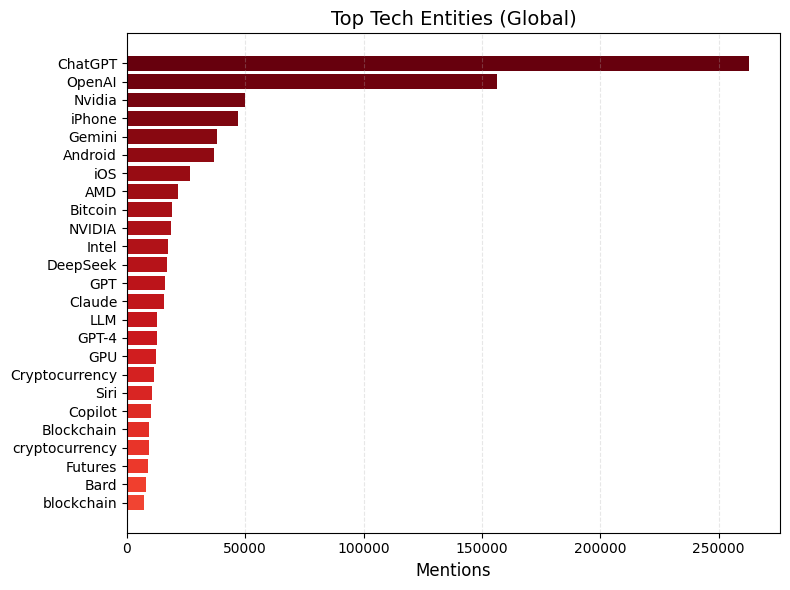

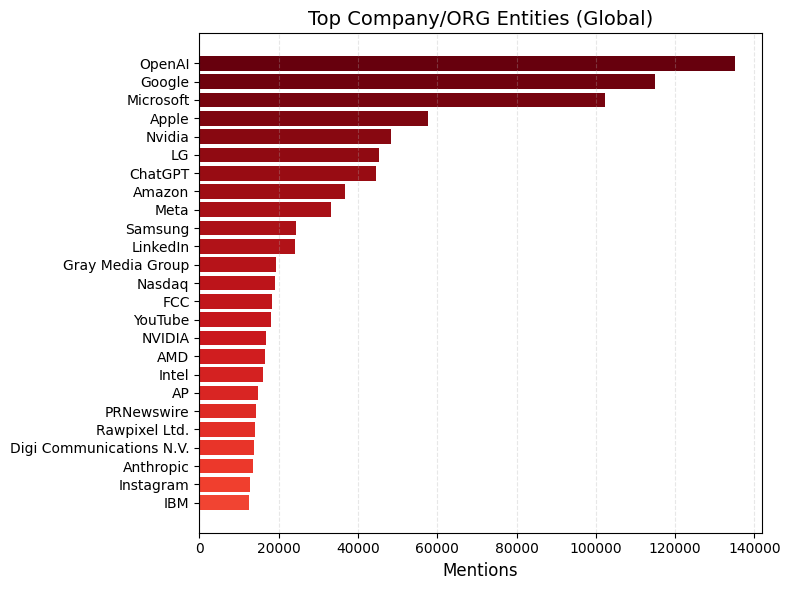

In [ ]:
dark_red = "#800000"
dark_red2 = "#5A0000"
dark_red3 = "#8B0000"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def global_top_entities(df, ents_col, topn=25):
    flat = [e for lst in df[ents_col].dropna() for e in lst]
    return pd.DataFrame(Counter(flat).most_common(topn), columns=["entity", "count"])

def plot_top_bar(d, title):
    d = d.sort_values("count")

    colors = plt.cm.Reds(np.linspace(0.6, 1.0, len(d)))  # dark red gradient

    plt.figure(figsize=(8, 6))
    plt.barh(d["entity"], d["count"], color=colors)

    plt.title(title, fontsize=14)
    plt.xlabel("Mentions", fontsize=12)

    plt.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

top_tech_global = global_top_entities(df, "tech_entities", topn=25)
top_org_global  = global_top_entities(df, "org_entities",  topn=25)

plot_top_bar(top_tech_global, "Top Tech Entities (Global)")
plot_top_bar(top_org_global,  "Top Company/ORG Entities (Global)")

In [ ]:
def top_entities_by_topic_from_df(df, topic_name_col, ents_col, topn=15):
    rows = []
    for tname, g in df.groupby(topic_name_col):
        flat = [e for lst in g[ents_col].dropna() for e in lst]
        for ent, c in Counter(flat).most_common(topn):
            rows.append({"topic_name": tname, "entity": ent, "count": c})
    return pd.DataFrame(rows)

top_tech_by_topic = top_entities_by_topic_from_df(df, "topic_name", "tech_entities", topn=15)
top_org_by_topic  = top_entities_by_topic_from_df(df, "topic_name", "org_entities",  topn=15)

def plot_top_entities_per_topic(top_df, title_prefix, n_topics=8, topn=10):
    topic_sizes = top_df.groupby("topic_name")["count"].sum().sort_values(ascending=False)
    keep_topics = topic_sizes.head(n_topics).index.tolist()

    for t in keep_topics:
        sub = (top_df[top_df["topic_name"] == t]
               .nlargest(topn, "count")
               .sort_values("count"))
        plt.figure(figsize=(9, 4.8))
        plt.barh(sub["entity"], sub["count"])
        plt.title(f"{title_prefix} — {t}")
        plt.xlabel("Mentions")
        plt.tight_layout()
        plt.show()

plot_top_entities_per_topic(top_tech_by_topic, "Top Tech Entities", n_topics=8, topn=10)
plot_top_entities_per_topic(top_org_by_topic,  "Top Company/ORG Entities", n_topics=8, topn=10)

NameError: name 'df' is not defined

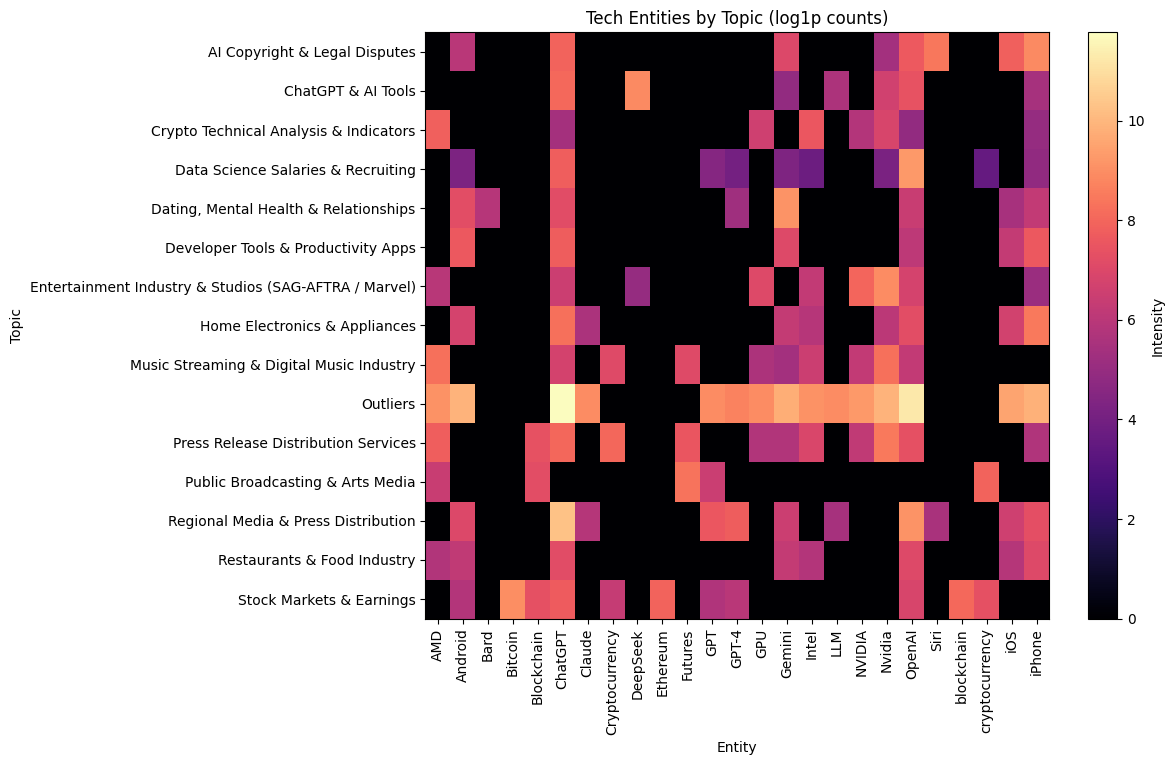

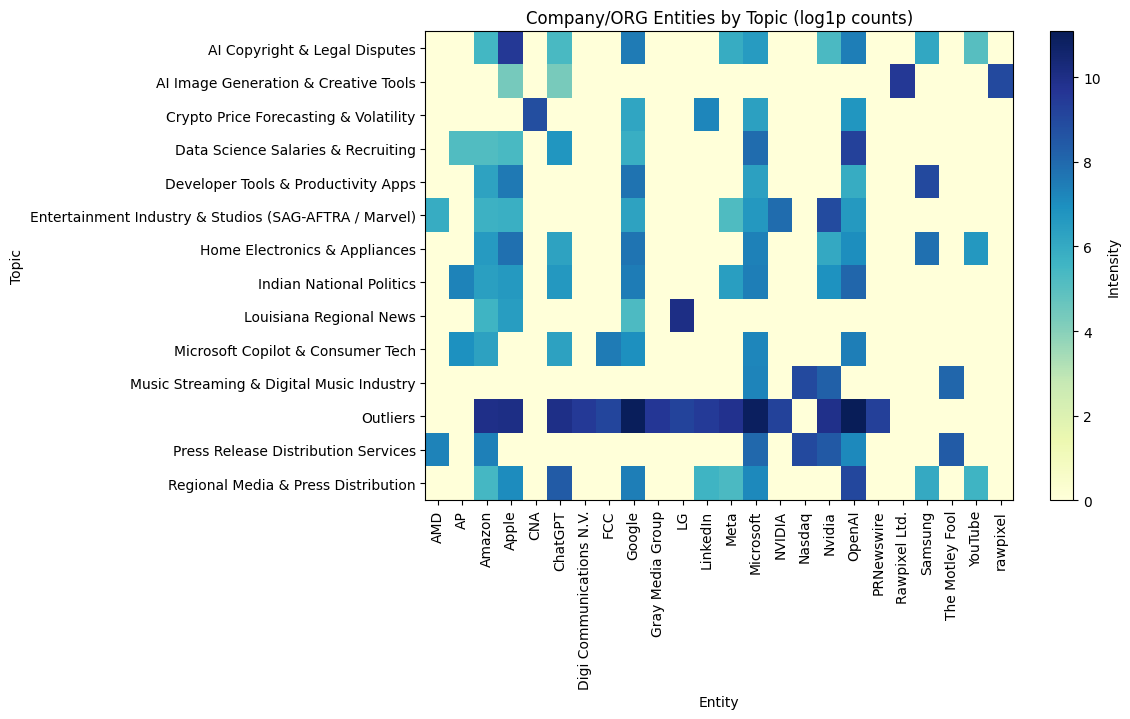

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_topic_entity_heatmap(top_df, title, n_topics=15, n_entities=25, log_scale=True, cmap="viridis"):
    # top_df columns: topic_name, entity, count
    top_topics = (top_df.groupby("topic_name")["count"]
                  .sum().sort_values(ascending=False).head(n_topics).index)
    top_entities = (top_df.groupby("entity")["count"]
                    .sum().sort_values(ascending=False).head(n_entities).index)

    sub = top_df[top_df["topic_name"].isin(top_topics) & top_df["entity"].isin(top_entities)]
    mat = sub.pivot_table(index="topic_name", columns="entity", values="count", fill_value=0)

    mat_plot = np.log1p(mat) if log_scale else mat
    title2 = title + (" (log1p counts)" if log_scale else "")

    plt.figure(figsize=(min(18, 1 + 0.45*mat_plot.shape[1]), min(10, 1 + 0.45*mat_plot.shape[0])))
    im = plt.imshow(mat_plot.values, aspect="auto", cmap=cmap)   # ✅ palette here
    plt.title(title2)
    plt.xlabel("Entity")
    plt.ylabel("Topic")
    plt.xticks(range(mat_plot.shape[1]), mat_plot.columns, rotation=90)
    plt.yticks(range(mat_plot.shape[0]), mat_plot.index)
    plt.colorbar(im, label="Intensity")
    plt.tight_layout()
    plt.show()

# Examples
plot_topic_entity_heatmap(top_tech_by_topic, "Tech Entities by Topic", cmap="magma")
plot_topic_entity_heatmap(top_org_by_topic,  "Company/ORG Entities by Topic", cmap="YlGnBu")

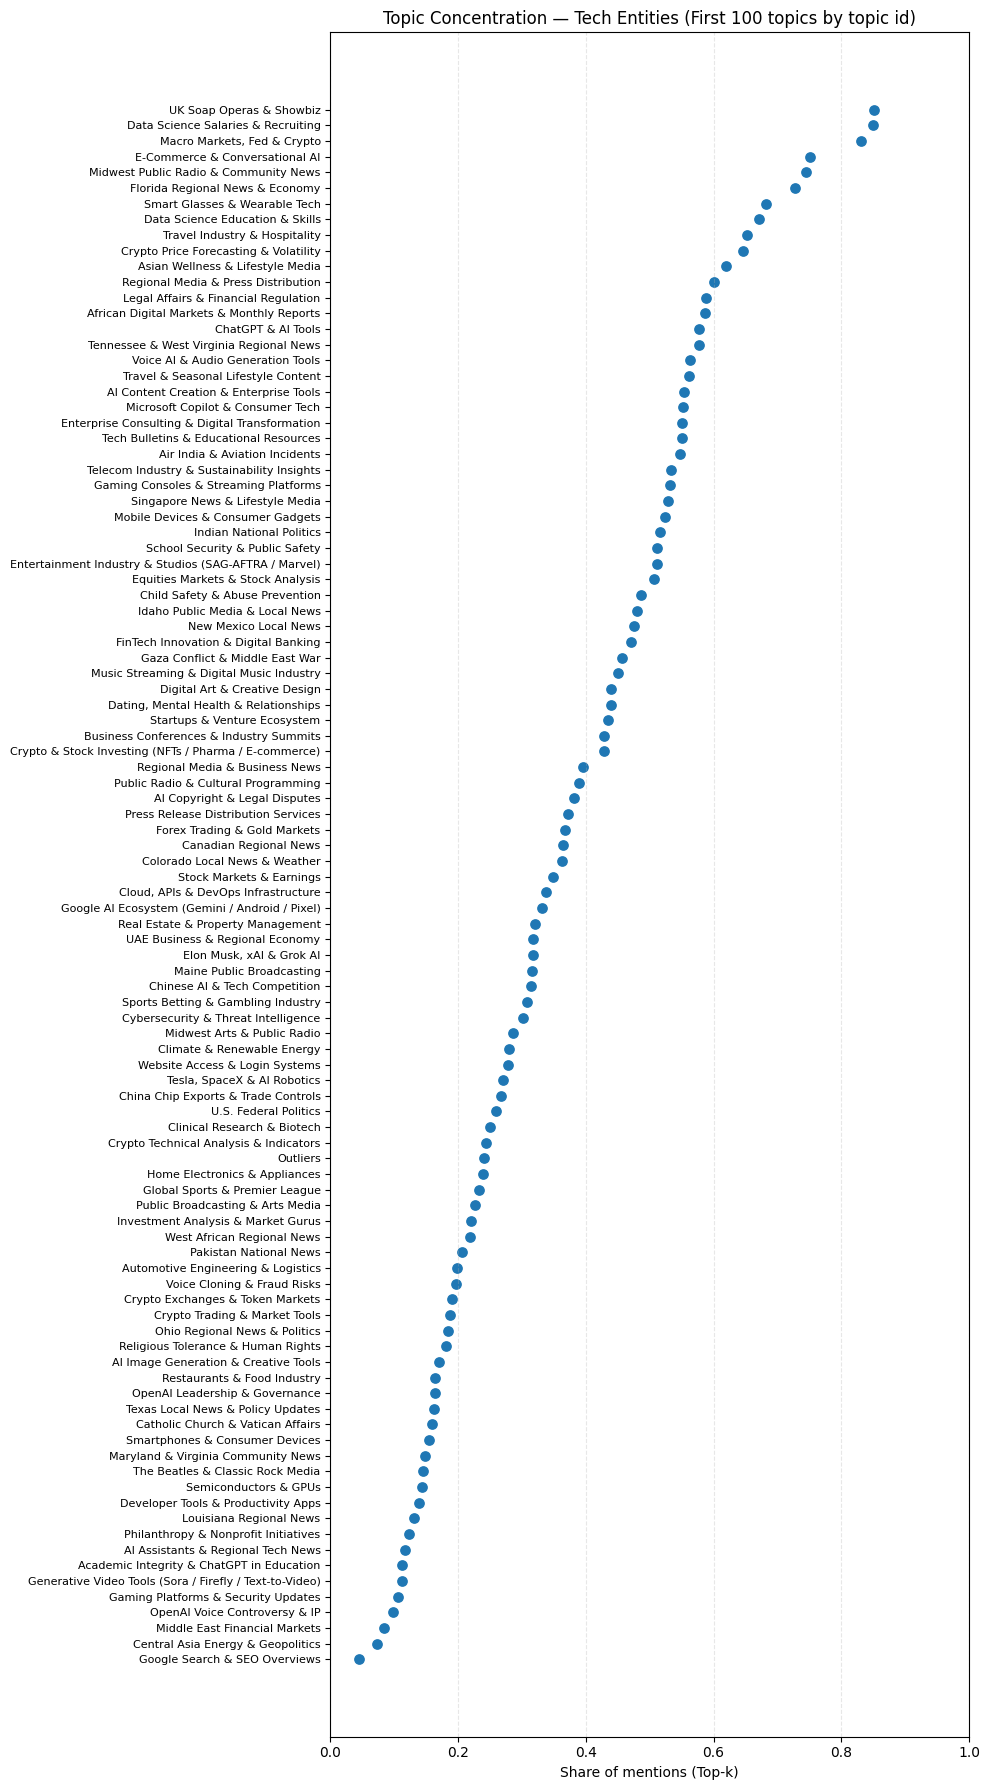

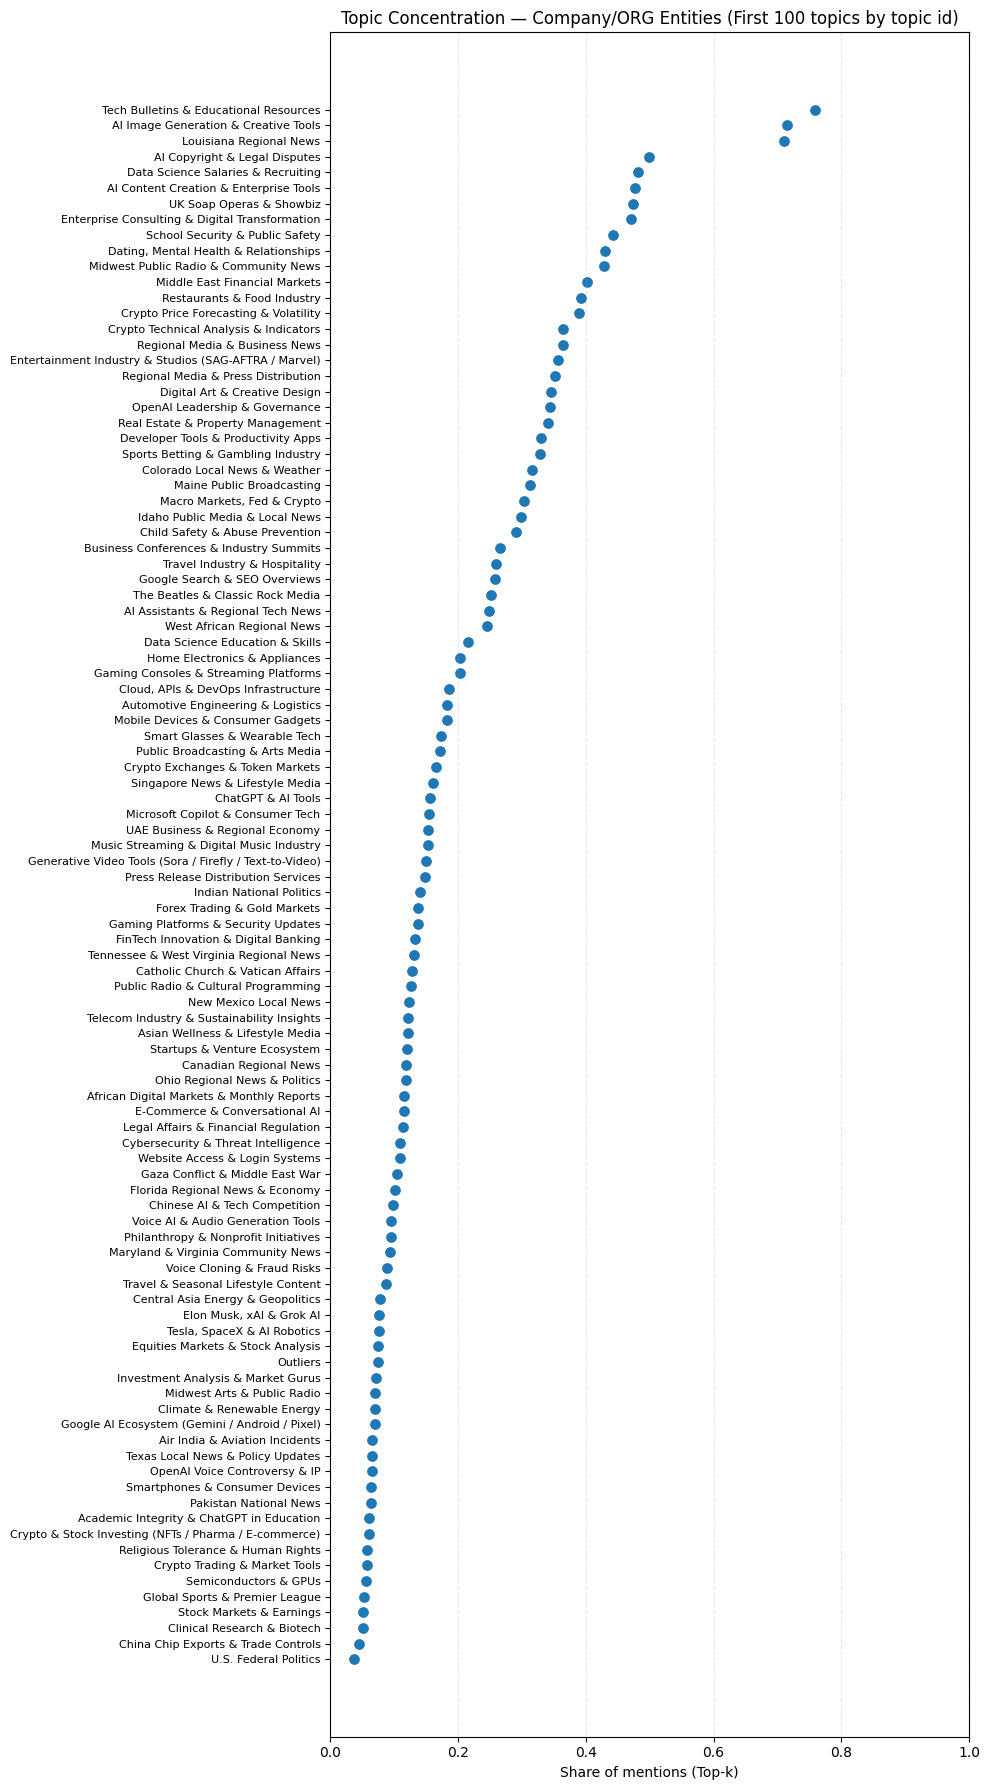

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def concentration_from_df_first100(df, ents_col, k=3):
    """
    df columns: topic, topic_name, <ents_col> where each row has a list of entities
    Returns: topic, topic_name, topk_share
    """
    rows = []
    for (tid, tname), g in df.groupby(["topic", "topic_name"]):
        flat = [e for lst in g[ents_col].dropna() for e in lst]
        if len(flat) == 0:
            continue
        counts = Counter(flat)
        total = sum(counts.values())
        topk = sum(c for _, c in counts.most_common(k))
        rows.append({"topic": int(tid), "topic_name": tname, f"top{k}_share": topk / total})

    out = pd.DataFrame(rows).sort_values("topic")
    first100_ids = sorted(out["topic"].unique())[:100]          # ✅ first 100 topic ids
    out = out[out["topic"].isin(first100_ids)].copy()
    return out

def plot_concentration_dot_first100(d, title):
    metric_col = [c for c in d.columns if c.startswith("top") and c.endswith("_share")][0]
    d_plot = d.sort_values(metric_col).reset_index(drop=True)

    y = np.arange(len(d_plot))
    plt.figure(figsize=(10, max(6, 0.18 * len(d_plot))))        # auto-height for 100 topics
    plt.scatter(d_plot[metric_col], y, s=45)
    plt.yticks(y, d_plot["topic_name"], fontsize=8)
    plt.xlabel("Share of mentions (Top-k)")
    plt.title(title + " (First 100 topics by topic id)")
    plt.xlim(0, 1)
    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

tech_conc_100 = concentration_from_df_first100(df, "tech_entities", k=3)
org_conc_100  = concentration_from_df_first100(df, "org_entities",  k=3)

plot_concentration_dot_first100(tech_conc_100, "Topic Concentration — Tech Entities")
plot_concentration_dot_first100(org_conc_100,  "Topic Concentration — Company/ORG Entities")

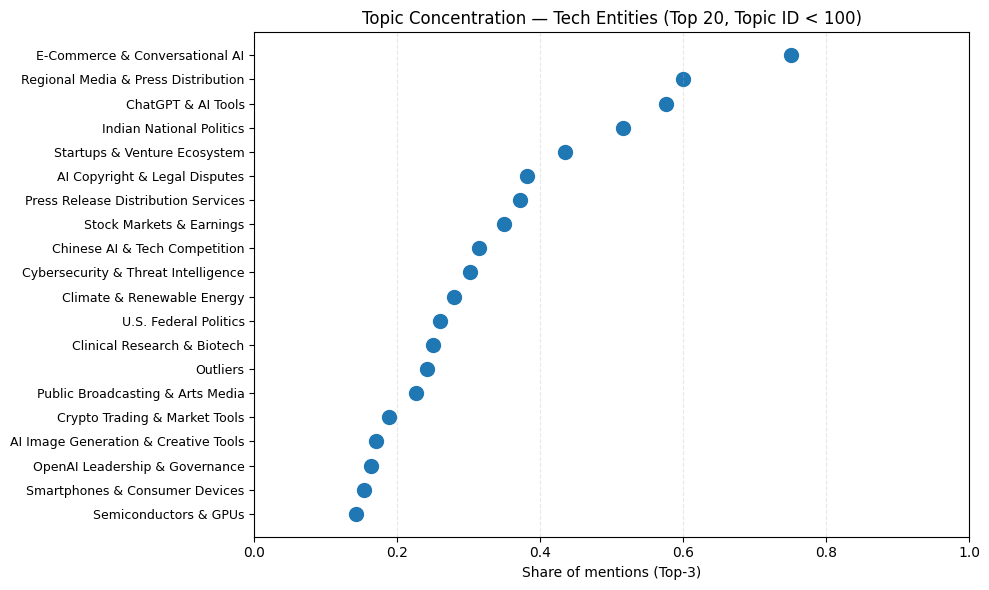

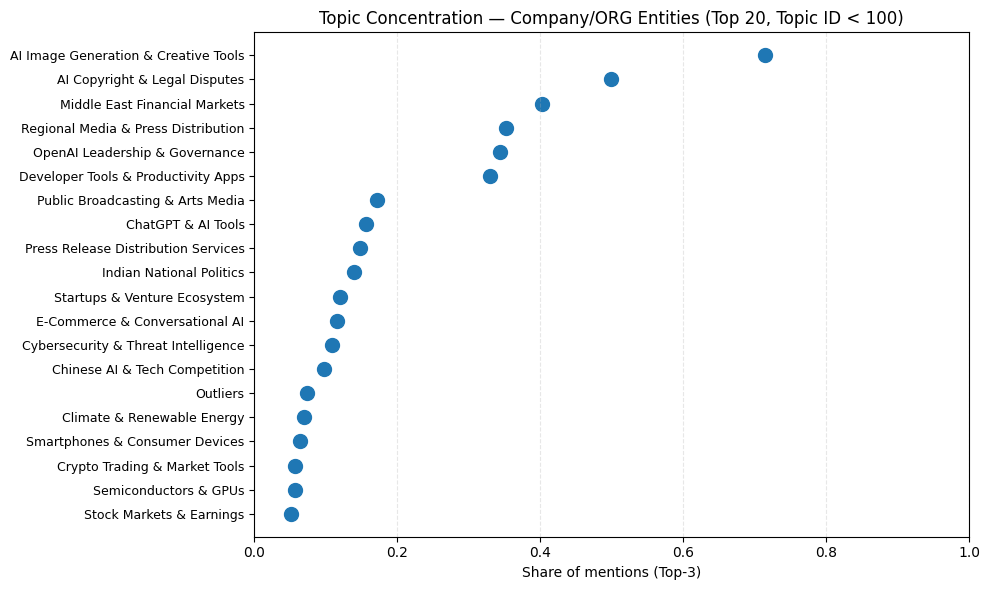

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def concentration_top20_under100(df, ents_col, k=3):
    """
    Rank by Top-k concentration
    Only include topics where topic id < 100
    Keep top 20
    """
    rows = []

    # 🔥 Filter topics < 100 first
    df_filtered = df[df["topic"] < 100]

    for (tid, tname), g in df_filtered.groupby(["topic", "topic_name"]):
        flat = [e for lst in g[ents_col].dropna() for e in lst]
        if len(flat) == 0:
            continue

        counts = Counter(flat)
        total = sum(counts.values())
        topk = sum(c for _, c in counts.most_common(k))

        rows.append({
            "topic": int(tid),
            "topic_name": tname,
            f"top{k}_share": topk / total
        })

    out = pd.DataFrame(rows)

    metric_col = f"top{k}_share"

    # 🔥 Rank by concentration
    out = out.sort_values(metric_col, ascending=False).head(20)

    return out

def plot_concentration_dot(d, title):
    metric_col = [c for c in d.columns if c.startswith("top") and c.endswith("_share")][0]

    d_plot = d.sort_values(metric_col).reset_index(drop=True)

    y = np.arange(len(d_plot))

    plt.figure(figsize=(10, 6))
    plt.scatter(d_plot[metric_col], y, s=100)

    plt.yticks(y, d_plot["topic_name"], fontsize=9)
    plt.xlabel("Share of mentions (Top-3)")
    plt.title(title + " (Top 20, Topic ID < 100)")
    plt.xlim(0, 1)
    plt.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


tech_top20 = concentration_top20_under100(df, "tech_entities", k=3)
org_top20  = concentration_top20_under100(df, "org_entities",  k=3)

plot_concentration_dot(tech_top20, "Topic Concentration — Tech Entities")
plot_concentration_dot(org_top20,  "Topic Concentration — Company/ORG Entities")

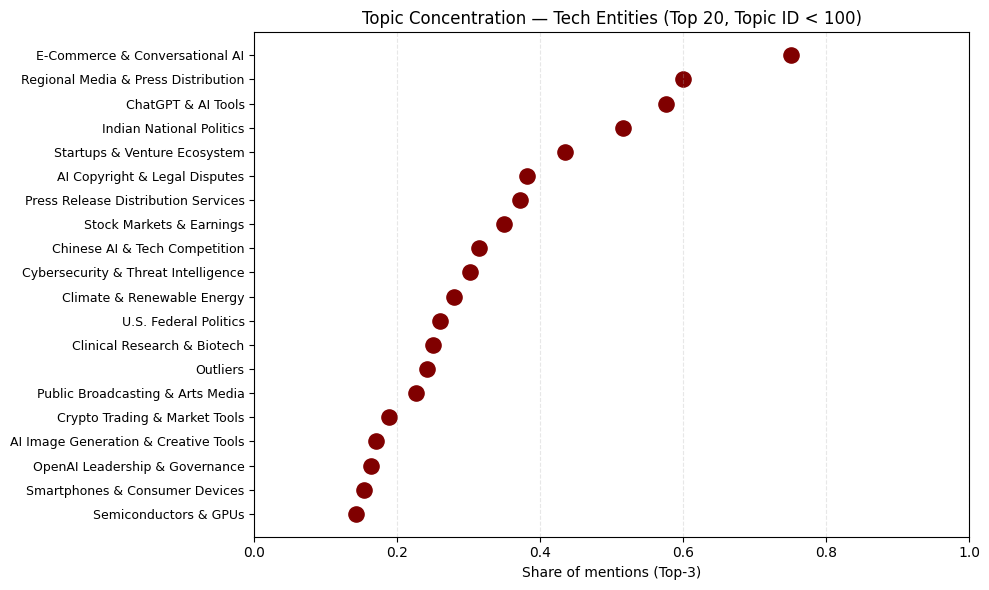

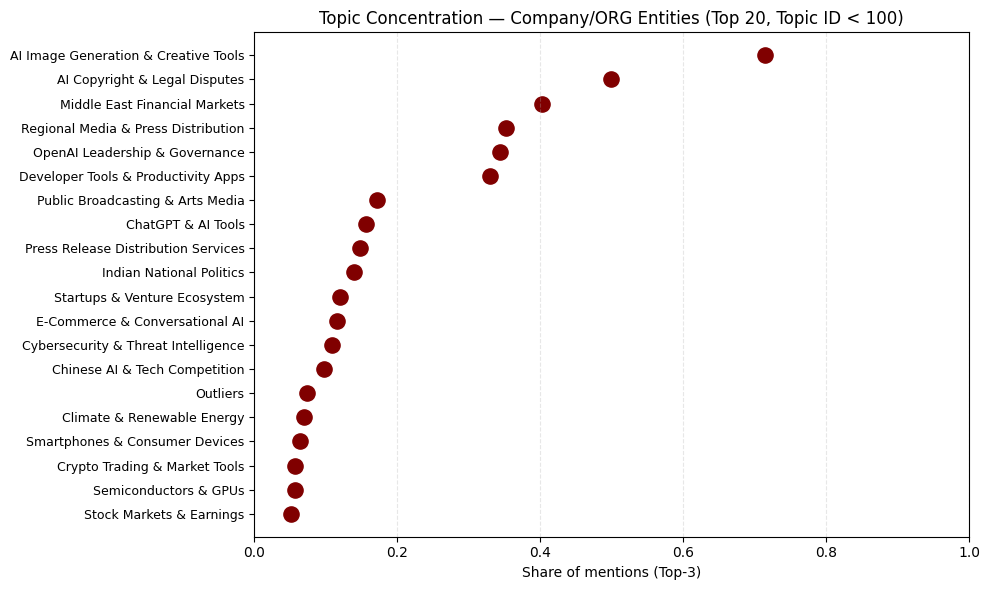

In [ ]:
def plot_concentration_dot(d, title):
    metric_col = [c for c in d.columns if c.startswith("top") and c.endswith("_share")][0]

    d_plot = d.sort_values(metric_col).reset_index(drop=True)

    y = np.arange(len(d_plot))

    uchicago_red = "#800000"

    plt.figure(figsize=(10, 6))
    plt.scatter(d_plot[metric_col], y, s=120, color=uchicago_red)

    plt.yticks(y, d_plot["topic_name"], fontsize=9)
    plt.xlabel("Share of mentions (Top-3)")
    plt.title(title + " (Top 20, Topic ID < 100)")
    plt.xlim(0, 1)

    plt.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()



tech_top20 = concentration_top20_under100(df, "tech_entities", k=3)
org_top20  = concentration_top20_under100(df, "org_entities",  k=3)

plot_concentration_dot(tech_top20, "Topic Concentration — Tech Entities")
plot_concentration_dot(org_top20,  "Topic Concentration — Company/ORG Entities")

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_network_colored_by_root(
    top_df,                   # columns: topic_name, entity, count
    title,
    n_roots=8,
    topn_per_root=8,
    min_count=3,
    cmap_name="tab20"
):
    # Select largest root topics
    root_sizes = top_df.groupby("topic_name")["count"].sum().sort_values(ascending=False)
    roots = root_sizes.head(n_roots).index.tolist()

    # Build graph edges
    edges = []
    for r in roots:
        sub = top_df[top_df["topic_name"] == r].copy()
        sub = sub[sub["count"] >= min_count].nlargest(topn_per_root, "count")
        for _, row in sub.iterrows():
            edges.append((f"R:{r}", f"E:{row['entity']}", int(row["count"])))

    G = nx.Graph()
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    root_nodes = [n for n in G.nodes if n.startswith("R:")]
    ent_nodes  = [n for n in G.nodes if n.startswith("E:")]

    # Assign root colors
    cmap = plt.get_cmap(cmap_name)
    root_color = {r: cmap(i % cmap.N) for i, r in enumerate(roots)}

    # Entity color = dominant connected root
    ent_color = {}
    for e in ent_nodes:
        neighbors = [(nbr, G[e][nbr]["weight"]) for nbr in G.neighbors(e) if nbr.startswith("R:")]
        if neighbors:
            best_root = max(neighbors, key=lambda x: x[1])[0][2:]
            ent_color[e] = root_color[best_root]
        else:
            ent_color[e] = (0.7, 0.7, 0.7, 1.0)

    # Layout
    pos = nx.spring_layout(G, k=1.2, iterations=150, seed=42)

    # Node sizes
    root_sizes_draw = [2800 + 350*G.degree(n) for n in root_nodes]
    ent_sizes_draw  = [ 300 +  60*G.degree(n) for n in ent_nodes]

    plt.figure(figsize=(15, 11))

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=root_nodes,
        node_size=root_sizes_draw,
        node_color=[root_color[n[2:]] for n in root_nodes],
        alpha=0.95
    )

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=ent_nodes,
        node_size=ent_sizes_draw,
        node_color=[ent_color[n] for n in ent_nodes],
        alpha=0.85
    )

    # Draw edges
    weights = np.array([G[u][v]["weight"] for u, v in G.edges], dtype=float)
    widths = 0.8 + 4.2*(weights - weights.min())/(weights.max() - weights.min() + 1e-9)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25)

    # 🔥 Label ONLY entity nodes
    entity_labels = {n: n[2:] for n in ent_nodes}
    nx.draw_networkx_labels(
        G, pos,
        labels=entity_labels,
        font_size=9
    )

    # Legend for roots
    handles = [Patch(facecolor=root_color[r], edgecolor="none", label=r) for r in roots]
    plt.legend(handles=handles, title="Root Topic", loc="best", frameon=True)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

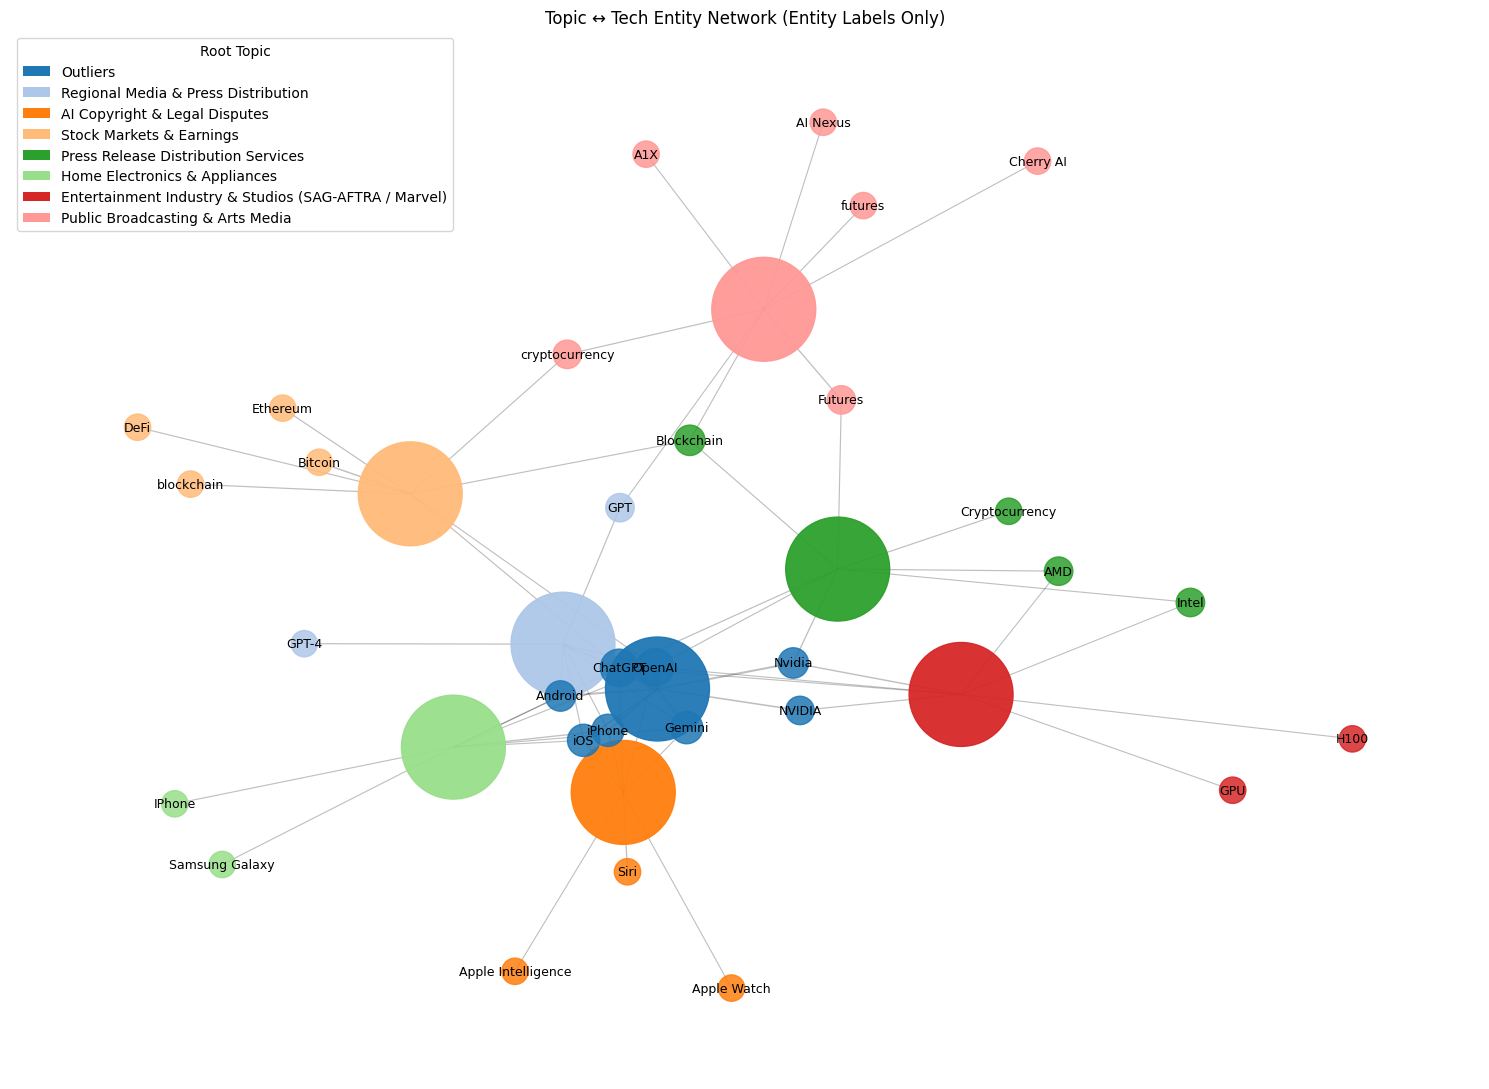

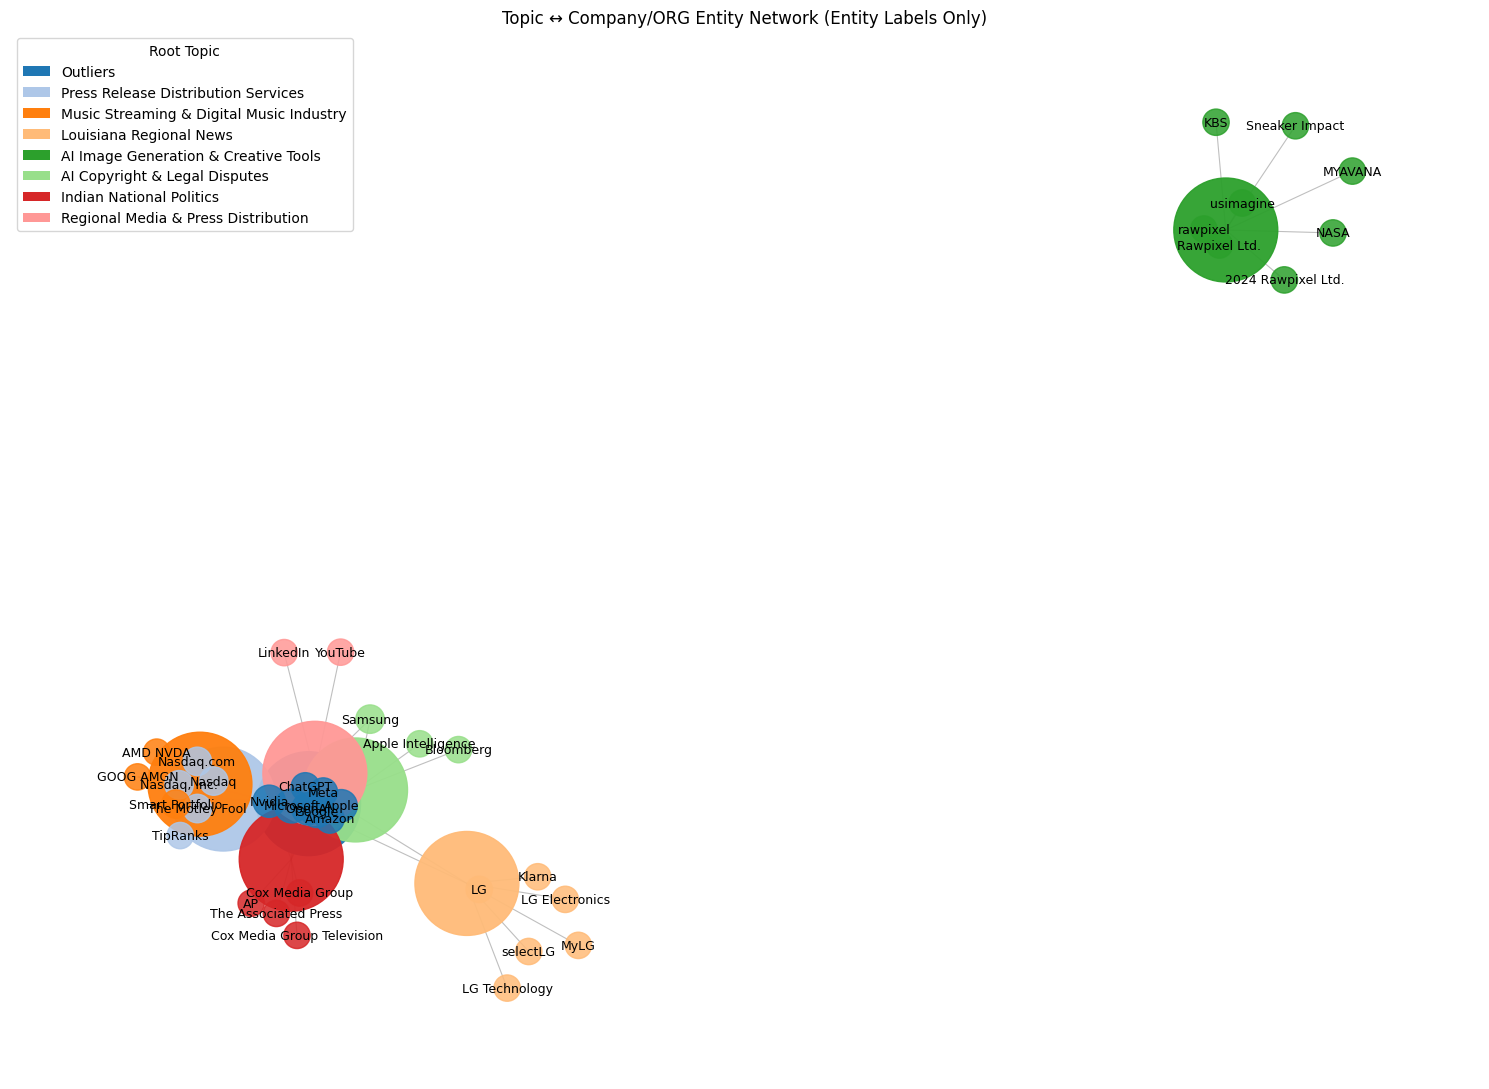

In [ ]:
plot_network_colored_by_root(
    top_tech_by_topic,
    "Topic ↔ Tech Entity Network (Entity Labels Only)",
    n_roots=8,
    topn_per_root=8,
    min_count=3
)

plot_network_colored_by_root(
    top_org_by_topic,
    "Topic ↔ Company/ORG Entity Network (Entity Labels Only)",
    n_roots=8,
    topn_per_root=8,
    min_count=3
)